In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [55]:
data = pd.read_csv('data/housing.csv')

In [56]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [58]:
data['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [59]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

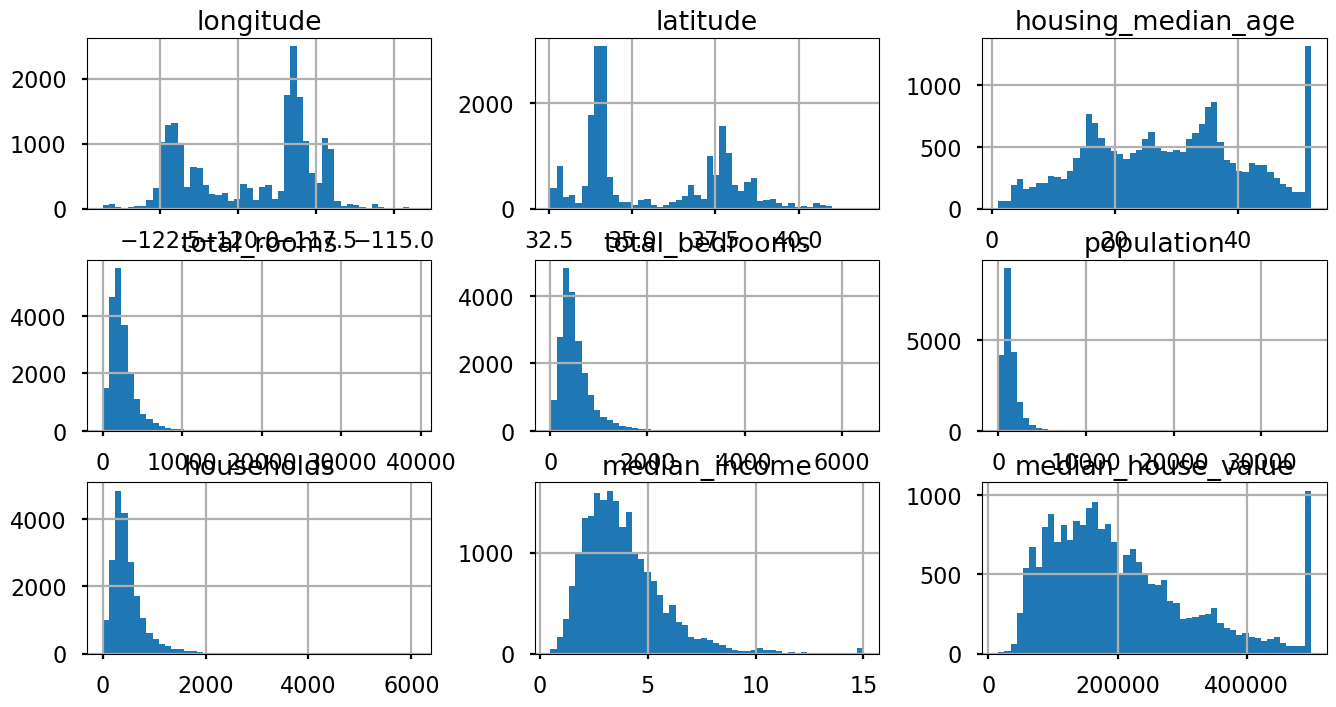

In [60]:
data.hist(bins=50, figsize=(16,8))

In [61]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [ ]:
df

In [62]:
data = data.fillna(435.000000)

In [63]:
data['Housing_income_cat'] = pd.cut(data['median_income'],
                                    bins=[0., 1.5, 3.0, 4.5, 6, np.inf],
                                    labels=[1, 2, 3, 4, 5])

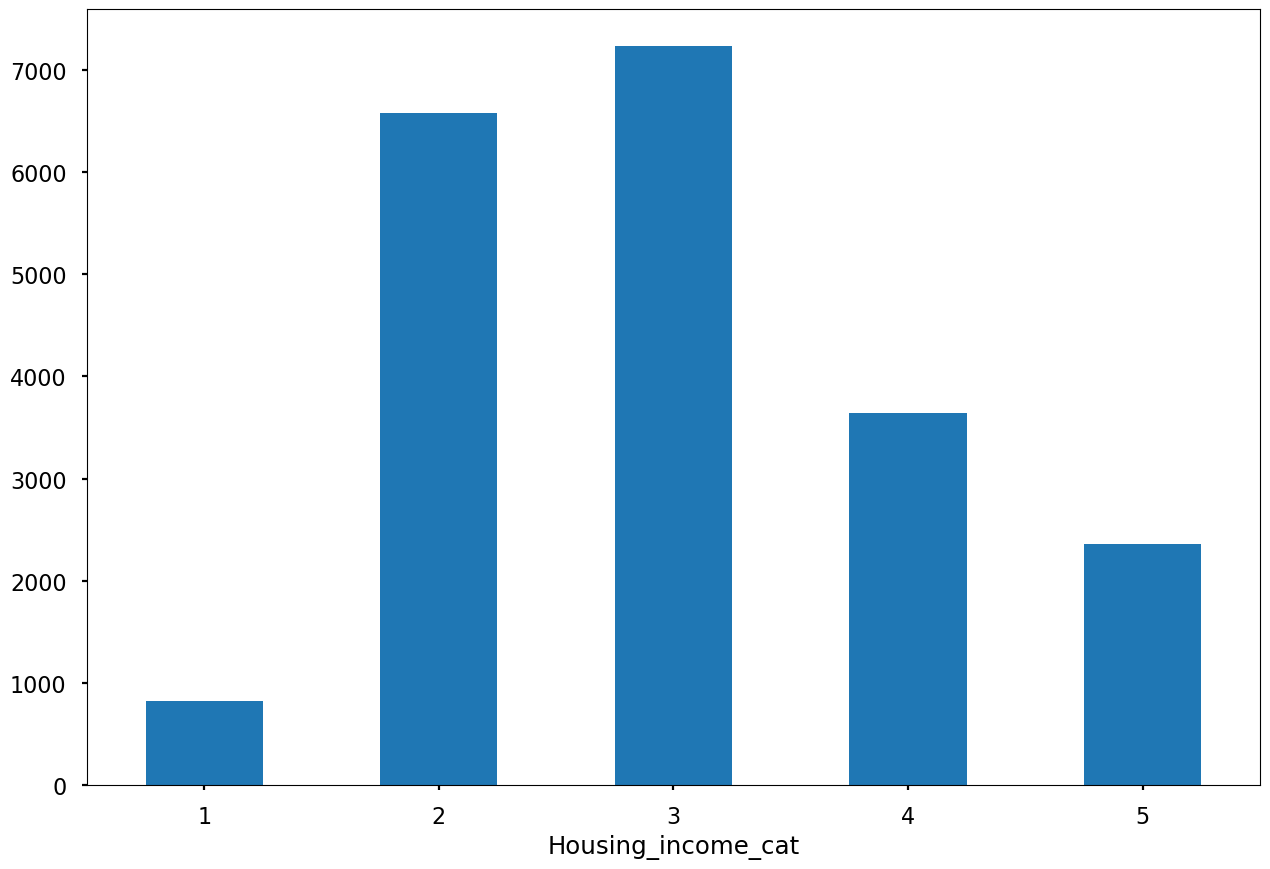

In [64]:
data['Housing_income_cat'].value_counts().sort_index().plot.bar(rot =0 , )
plt.tight_layout()

In [65]:
plt.style.use('seaborn-v0_8-poster')

In [66]:
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
spliter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=34)

In [67]:
strat_split = [] 
for train_index, test_index in spliter.split(data, data['Housing_income_cat']):
    start_test_set_n = data.iloc[train_index]
    start_train_set_n = data.iloc[test_index]
    strat_split.append([start_train_set_n, start_test_set_n])
    

In [68]:
start_train_set, start_test_set = train_test_split(
    data, test_size=0.2, stratify=data['Housing_income_cat'], random_state=42
)

In [69]:
# data = start_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

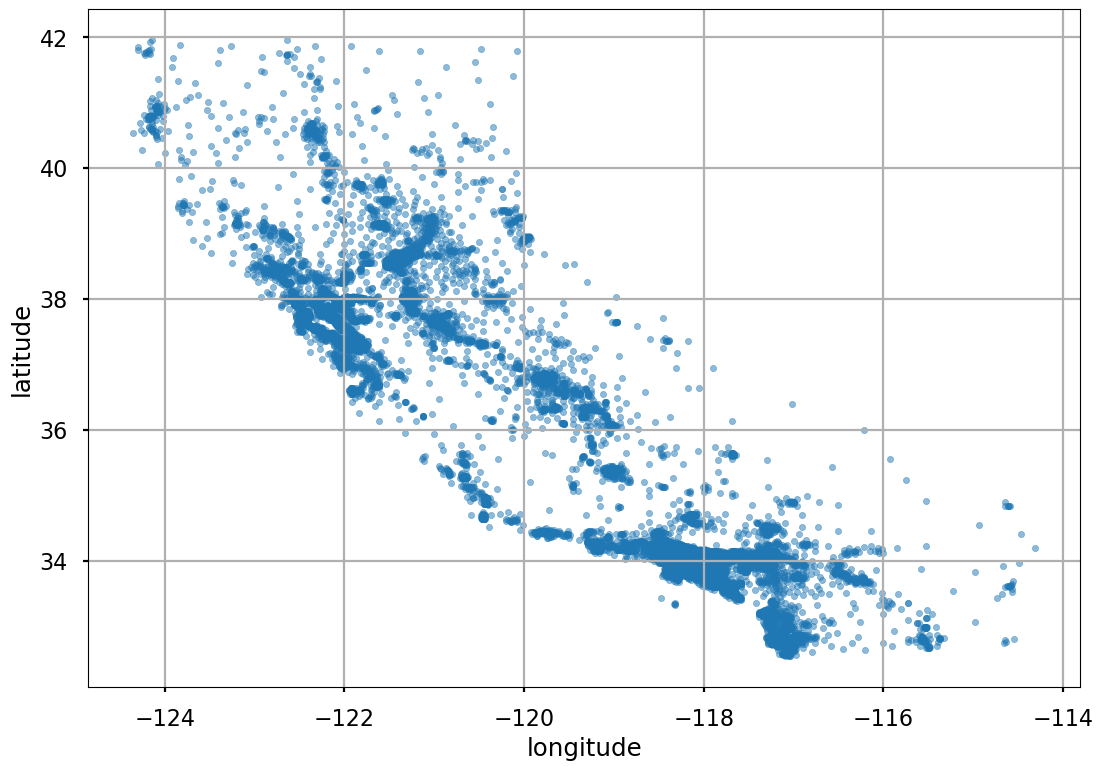

In [70]:
data.plot(kind="scatter", x="longitude", y="latitude", grid = True, alpha=0.5)

<Axes: xlabel='longitude', ylabel='latitude'>

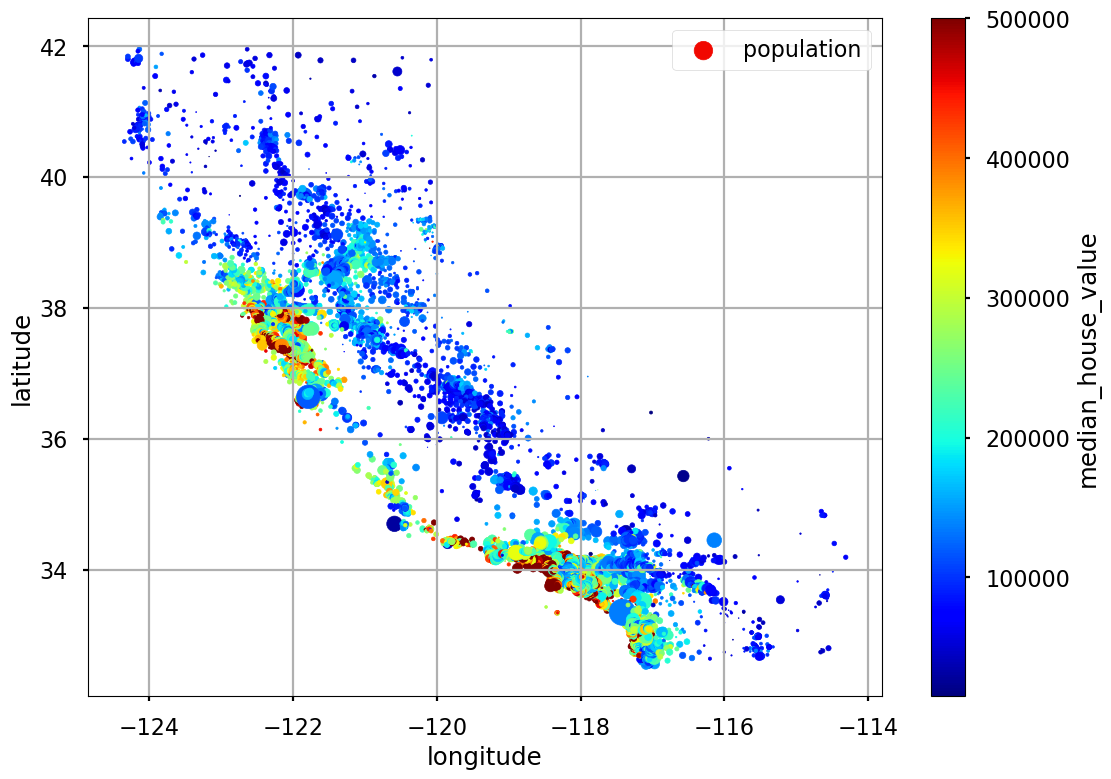

In [71]:
data.plot(kind="scatter", x="longitude", y="latitude", grid = True, s=data['population']/100, label = "population", c='median_house_value', cmap='jet', colorbar=True)

<Axes: xlabel='longitude', ylabel='latitude'>

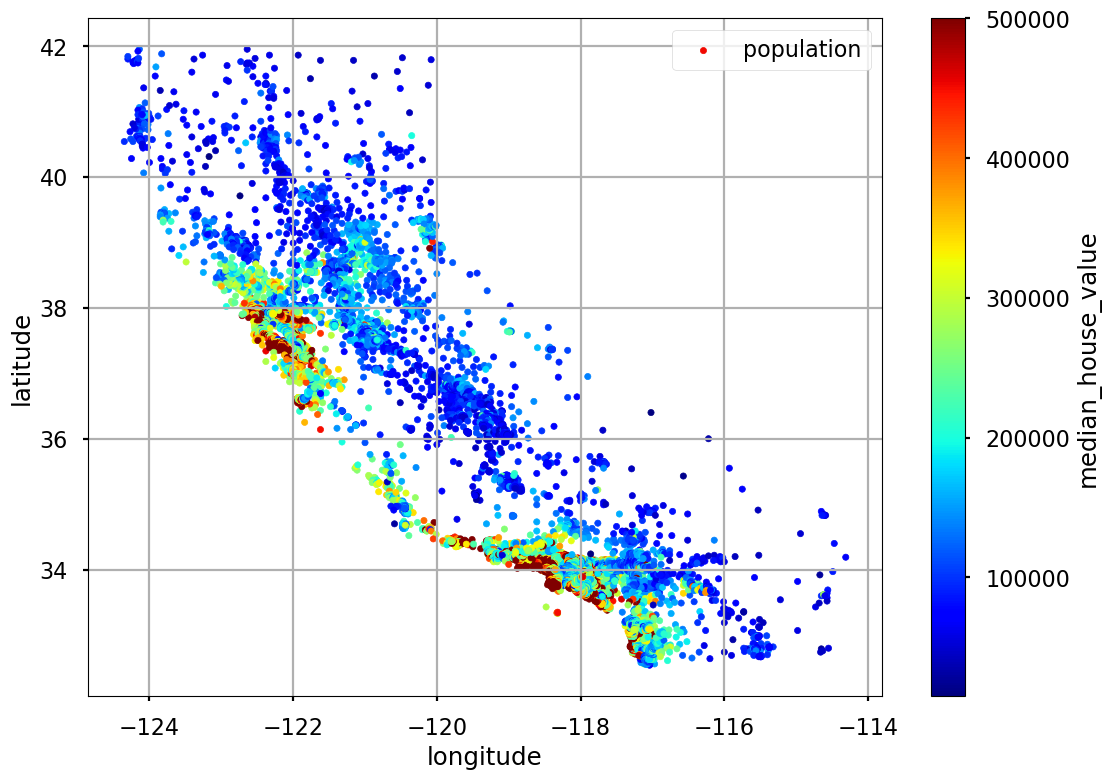

In [72]:
data.plot(kind="scatter", x="longitude", y="latitude", grid = True,  label = "population", c='median_house_value', cmap='jet', colorbar=True)

In [78]:
## Correlation 
corr_matrix =data.drop('ocean_proximity',axis=1).corr()

In [91]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

<Axes: >

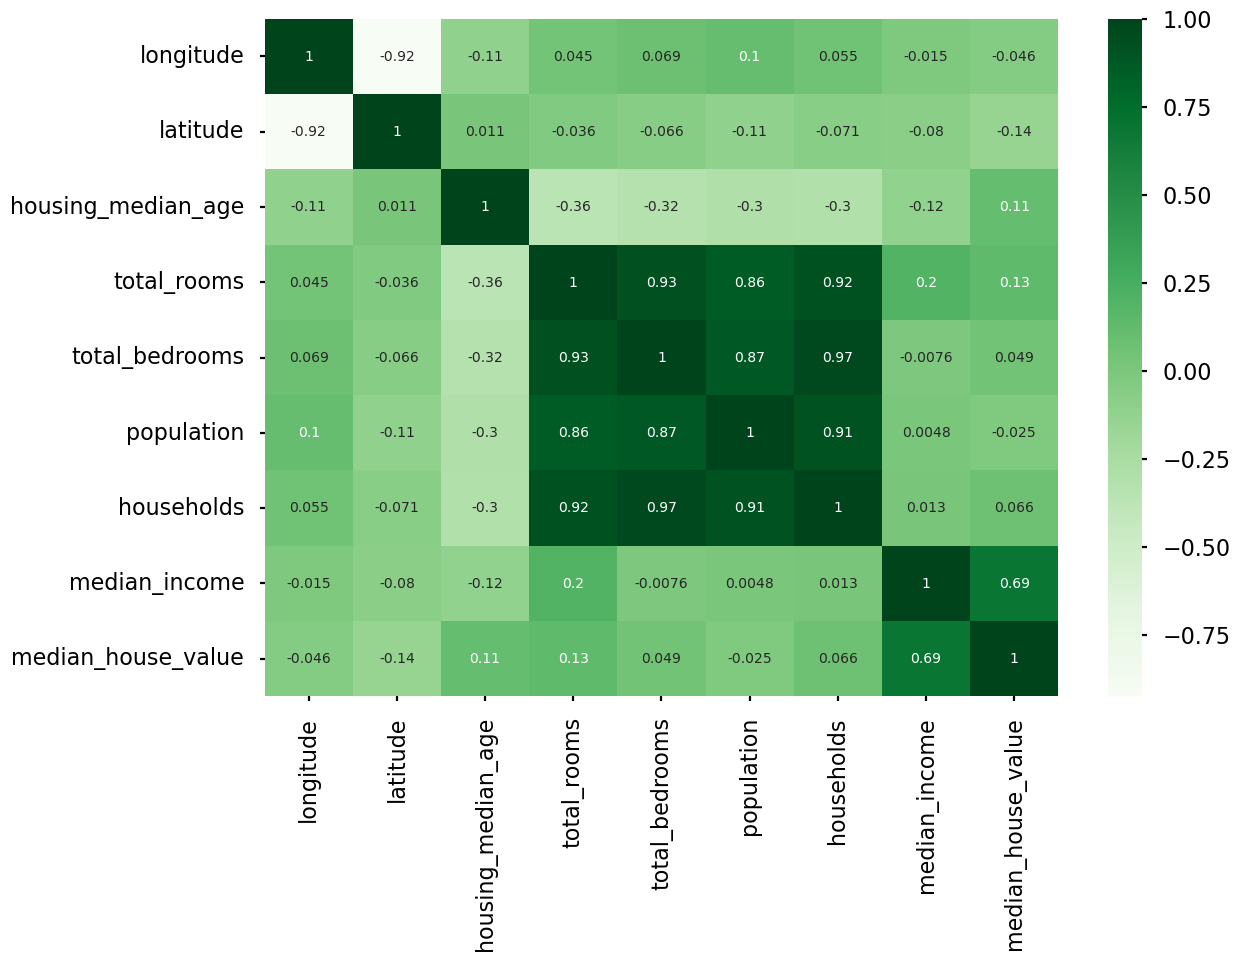

In [85]:
sns.heatmap(data.drop('ocean_proximity',axis=1).corr(), cmap="Greens", annot=True)

In [87]:
from pandas.plotting import scatter_matrix

In [92]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

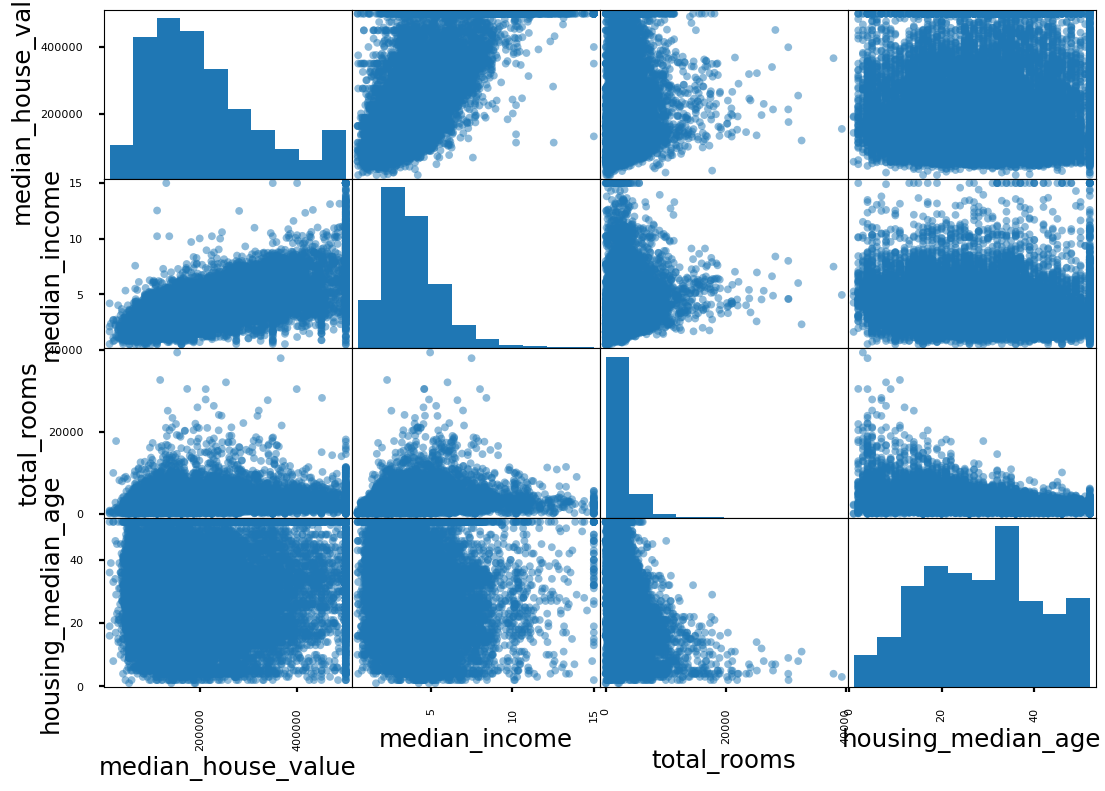

In [96]:
scatter_matrix(data[['median_house_value', 'median_income','total_rooms', 'housing_median_age', ]])

In [102]:
x_train = start_train_set.drop(['median_house_value', "Housing_income_cat"], axis=1, )
y_train = start_train_set['median_house_value']

In [104]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [ ]:
num_x = x_train.select_dtypes(include=[np.number])

In [107]:
imputer.fit(num_x)

SimpleImputer(strategy='median')

In [108]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  435.     ,
       1164.     ,  408.     ,    3.54155])

In [109]:
x_train['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     7277
INLAND        5262
NEAR OCEAN    2124
NEAR BAY      1847
ISLAND           2
Name: count, dtype: int64